<a href="https://colab.research.google.com/github/pzedros/metodos_numericos/blob/main/trabalho_3_razao_aurea.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

    Iterações  Valores Mínimos de r     Ea (%)
0           1              6.940732  33.671853
1           2              5.772195  25.023244
2           3              5.050000  17.676880
3           4              4.603659  11.984122
4           5              4.879513   6.987877
5           6              5.050000   4.172945
6           7              4.944633   2.633979
7           8              5.009753   1.606728
8           9              4.969507   1.001055
9          10              4.994381   0.615605
10         11              5.009753   0.379297
11         12              5.000253   0.234864
12         13              4.994381   0.145325
13         14              4.998010   0.089750
14         15              5.000253   0.055444
15         16              4.998866   0.034276
16         17              4.999723   0.021180
17         18              5.000253   0.013089
18         19              4.999925   0.008090
19         20              5.000128   0.004999
20         21

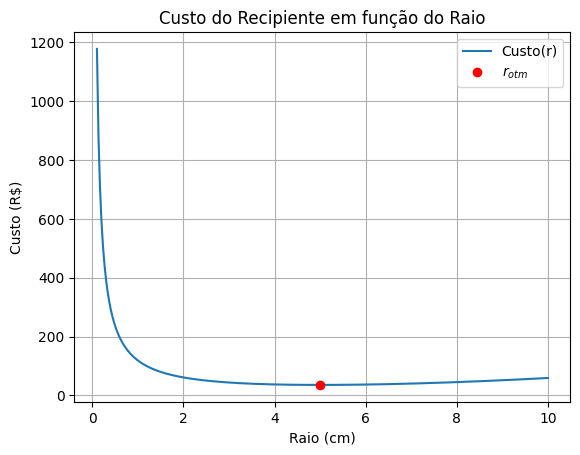

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Função custo em função de r
def custo(r):
    return 0.15 * np.pi * r**2 + (37.5 * np.pi) / r

# Limites iniciais para r (>0)
rl = 0.1
ru = 10

# Gráfico da função
r_vals = np.linspace(0.1, 10, 300)
c_vals = custo(r_vals)

# Método da razão áurea
phi = (1 + np.sqrt(5)) / 2
d = (phi - 1) * (ru - rl)
r1 = rl + d
r2 = ru - d

Ea = np.inf
n = 6
Eppara = 0.5 * 10**(2 - n)
i = 0

minimos = []
erros = []
iteracoes = []

while Ea > Eppara:
    if custo(r1) < custo(r2):
        rl = r2
        r2 = r1
        d = (phi - 1) * (ru - rl)
        r1 = rl + d
    else:
        ru = r1
        r1 = r2
        d = (phi - 1) * (ru - rl)
        r2 = ru - d

    rotm = (rl + ru) / 2
    hotm = 375 / rotm**2
    Ea = (2 - phi) * abs((ru - rl) / rotm) * 100
    i += 1

    minimos.append(rotm)
    iteracoes.append(i)
    erros.append(Ea)


# Tabela com resultados
table = pd.DataFrame({
    'Iterações': iteracoes,
    'Valores Mínimos de r': minimos,
    'Ea (%)': erros,

})
print(table)

# Resultado final
r_otimo = rotm
h_otimo = hotm
c_min = custo(r_otimo)

print(f"Dimensões ótimas:")
print(f"Raio ótimo: {r_otimo:.4f} cm")
print(f"Altura ótima: {h_otimo:.4f} cm")
print(f"Custo mínimo: R$ {c_min:.2f}")

# Gráfico
plt.plot(r_vals, c_vals, label='Custo(r)')
plt.plot(r_otimo, c_min, 'ro', label = '$r_{otm}$')  # bolinha vermelha no ponto mínimo
plt.xlabel('Raio (cm)')
plt.ylabel('Custo (R$)')
plt.title('Custo do Recipiente em função do Raio')
plt.legend()
plt.grid(True)
plt.show()


 Iteração       x1       x2       x3       x4     f(x4)   Erro (%)
        1 0.100000 7.861328 6.000000 6.851397 39.315722 100.000000
        2 7.861328 6.851397 6.000000 4.517170 35.695974  51.674544
        3 6.851397 4.517170 6.000000 4.983023 35.343326   9.348791
        4 4.517170 4.983023 6.000000 5.031812 35.344342   0.969612
        5 4.517170 5.031812 4.983023 5.000527 35.342918   0.625638
        6 5.031812 5.000527 4.983023 5.000035 35.342917   0.009821
        7 5.000527 5.000035 4.983023 5.000001 35.342917   0.000696
        8 5.000035 5.000001 4.983023 5.000000 35.342917   0.000012

=== Resultado Final ===
Raio ótimo (r): 5.000000 cm
Altura correspondente (h): 15.000000 cm
Custo mínimo: R$ 35.34
Número de iterações: 8


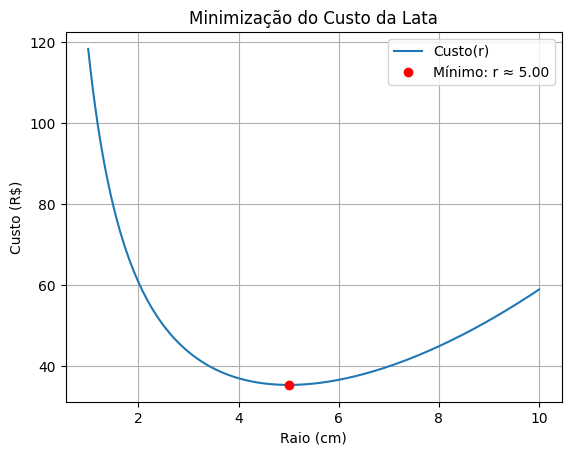

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import math

# Função de custo
def f(r):
    return 0.15 * np.pi * r**2 + (37.5 * np.pi) / r

# Precisão desejada
n = 6
Eppara = 0.5 * (10 ** (2 - n))
epest = 100

# Pontos iniciais
x1 = 0.1
x2 =6
x3 = 10

xold = 0

# Tabela de iterações
tabela = []

# Primeira estimativa de x4
x4old = x2 - (0.5 * (((x2 - x1)**2) * (f(x2) - f(x3)) - ((x2 - x3)**2) * (f(x2) - f(x1))) /
             (((x2 - x1) * (f(x2) - f(x3)) - (x2 - x3) * (f(x2) - f(x1)))))

# Iterações
iteracao = 0
while epest >= Eppara:
    iteracao += 1

    if f(x4old) < f(x2):
        x1 = x2
        x2 = x4old
    else:
        x3 = x2
        x2 = x4old

    x4new = x2 - (0.5 * (((x2 - x1)**2) * (f(x2) - f(x3)) - ((x2 - x3)**2) * (f(x2) - f(x1))) /
                 (((x2 - x1) * (f(x2) - f(x3)) - (x2 - x3) * (f(x2) - f(x1)))))

    epest = abs((x4new - xold) / x4new) * 100
    xold = x4new
    x4old = x4new

    tabela.append([iteracao, x1, x2, x3, x4new, f(x4new), epest])

# Resultados finais
r_min = x4new
h_min = 375 / r_min**2
custo_min = f(r_min)

# Mostrar tabela
df = pd.DataFrame(tabela, columns=['Iteração','x1', 'x2', 'x3','x4', 'f(x4)', 'Erro (%)'])
print(df.to_string(index=False))

# Mostrar resultados finais
print("\n=== Resultado Final ===")
print(f"Raio ótimo (r): {r_min:.6f} cm")
print(f"Altura correspondente (h): {h_min:.6f} cm")
print(f"Custo mínimo: R$ {custo_min:.2f}")
print(f"Número de iterações: {iteracao}")

# Gráfico
x = np.linspace(1, 10, 200)
plt.plot(x, f(x), label="Custo(r)")
plt.plot(r_min, custo_min, 'ro', label=f"Mínimo: r ≈ {r_min:.2f}")
plt.xlabel("Raio (cm)")
plt.ylabel("Custo (R$)")
plt.title("Minimização do Custo da Lata")
plt.grid(True)
plt.legend()
plt.show()
